## Further Adaptations

In [1]:
import socket
print(f"Running on: {socket.gethostname()}")

Running on: damnii02.inf.ed.ac.uk


In [2]:
# check CUDA available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device count: 2
Current device: 0
Device name: NVIDIA GeForce RTX 2080 Ti


## Import Necessary Modules

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import T5Tokenizer, T5ForConditionalGeneration # huggingface T5 model + tokenizer
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import torchmetrics
from dynamic import FeatureProjector, MultitaskModelWithProjection, ProjectionExperimentDataset, create_experiment_pipeline, evaluate_with_sampling, train, train_and_validate_model_with_meteor_rouge, train_and_validate_model_with_meteor_stopping, METEOREarlyStopping, display_generated_texts, print_test_evaluation, compute_rougeL
from sklearn.model_selection import train_test_split
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score
import nltk
import random
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import T5ForConditionalGeneration, T5Tokenizer

## Set Random Seed, For Reproducibility

In [ ]:
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Load Dataset and Extract Features

In [ ]:
mwr_df = pd.read_csv('mwr.csv')

In [ ]:
print(mwr_df.columns)

In [ ]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df.columns if col.endswith('int') or col.endswith('sk')]
mwr_df['features'] = mwr_df[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df['class_label'] = mwr_df['y_binary'].astype(int)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

## Split Data into Test, Train and Validation

In [ ]:
# 70% training, 15% validation, 15% testing
from sklearn.model_selection import train_test_split

# Stratified split on 'r:Th' column
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df['r:Th']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['r:Th']
)

## Dynamic Weighting

In [9]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='concat',
        projection_type='mlp',
        use_minimal_text=True,
        dynamic_loss_weighting=True,
        initial_class_weight=0.1,
        initial_gen_weight=10.0
    )


EXPERIMENT: CONCAT projection + MINIMAL text
Projection type: mlp
Dynamic loss weighting: ENABLED
Initial weights - Classification: 0.1, Generation: 10.0


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: True
  Feature projection: Yes
  Dynamic loss weighting: True


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 4.7589
Classification loss: 0.6226
Generation loss: 2.5208
Weighted gen loss: 0.492226
Validation loss: 0.7498
Validation metrics:
  Accuracy     : 0.7459
  F1-Score     : 0.7200
  Sensitivity  : 0.8995
  Specificity  : 0.2645
  AUC-ROC      : 0.6829

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3774
  ✓ New best METEOR: 0.3774
  ROUGE-L F1   : 0.3854
  ✓ New best ROUGE-L F1: 0.3854
✓ New best accuracy: 0.7459
✓ New best F1: 0.7200
✓ New best AUC-ROC: 0.6829

Epoch 2/50
Training loss: 0.7942
Classification loss: 0.5523
Generation loss: 1.6877
Weighted gen loss: 0.402020
Validation loss: 0.7032
Validation metrics:
  Accuracy     : 0.7500
  F1-Score     : 0.7443
  Sensitivity  : 0.8544
  Specificity  : 0.4230
  AUC-ROC      : 0.7319

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
 

  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 17/50
Training loss: 0.5814
Classification loss: 0.4630
Generation loss: 0.7515
Weighted gen loss: 0.306841
Validation loss: 0.5651
Validation metrics:
  Accuracy     : 0.7677
  F1-Score     : 0.7718
  Sensitivity  : 0.8282
  Specificity  : 0.5781
  AUC-ROC      : 0.8024

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best F1: 0.7718
✓ New best AUC-ROC: 0.8024

Epoch 18/50
Training loss: 0.5777
Classification loss: 0.4609
Generation loss: 0.7424
Weighted gen loss: 0.308430
Validation loss: 0.5625
Validation metrics:
  Accuracy     : 0.7688
  F1-Score     : 0.7716
  Sensitivity  : 0.8355
  Specificity  : 0.5599
  AUC-ROC      : 0.7995

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
 

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best accuracy: 0.7823
✓ New best F1: 0.7831
Current loss weights - CLF: 0.553, GEN: 0.447

Epoch 34/50
Training loss: 0.5321
Classification loss: 0.4341
Generation loss: 0.6511
Weighted gen loss: 0.306718
Validation loss: 0.5449
Validation metrics:
  Accuracy     : 0.7528
  F1-Score     : 0.7637
  Sensitivity  : 0.7823
  Specificity  : 0.6602
  AUC-ROC      : 0.8111

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 35/50
Training loss: 0.5352
Classification loss: 0.4359
Generation loss: 0.6476
Weighted gen loss: 0.303882
Validation loss: 0.5239
Validation metrics:
  Accuracy     : 0.7779
  F1-Score     : 0.7820
  Sensitivity  : 0.8344
  Specificity  : 0.6009
  AUC-ROC      : 0.8235

--- Text Evaluation (Epoch 35) ---
Evaluating text generation on FULL d

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145


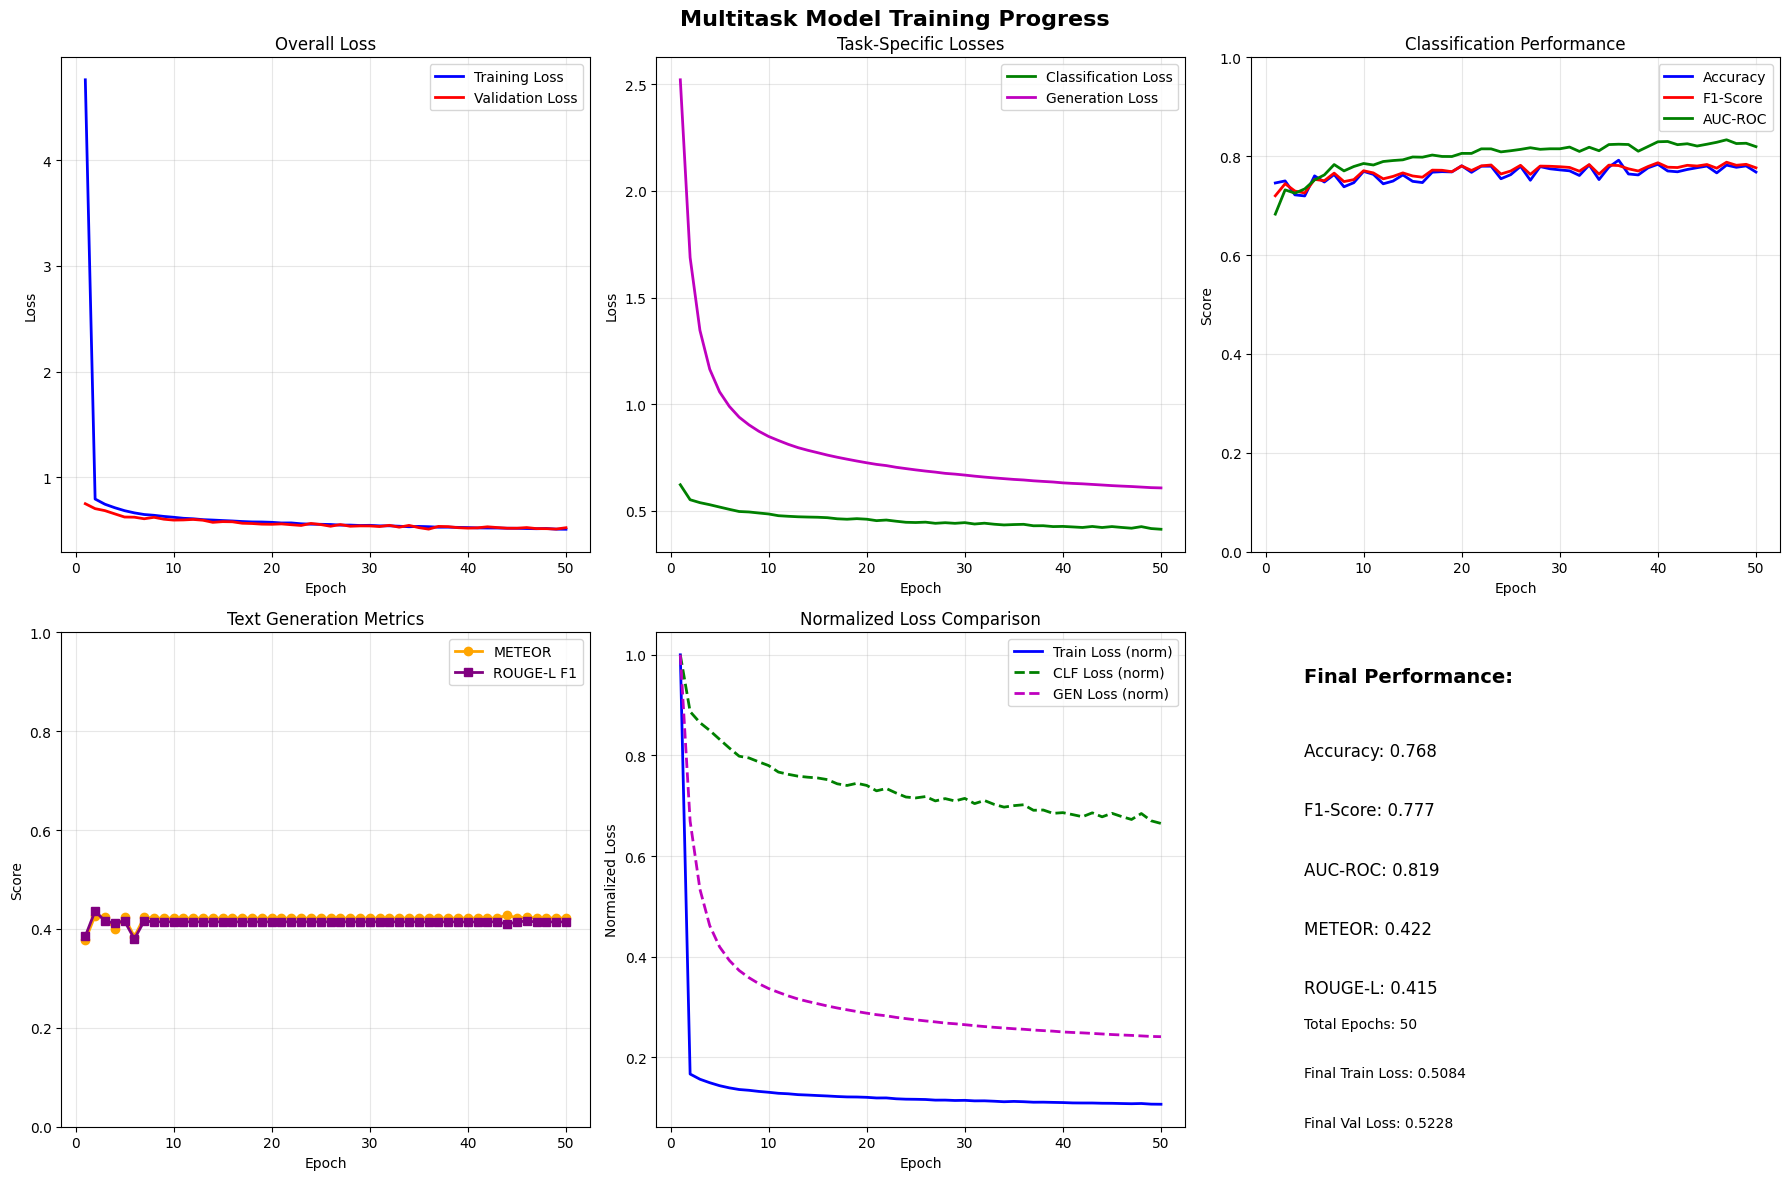


TRAINING SUMMARY
Best Accuracy: 0.7919
Best F1-Score: 0.7879
Best AUC-ROC: 0.8332
Best METEOR: 0.4279
Best ROUGE-L: 0.4366


In [10]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 0.5092
Classification metrics (all 3625 samples):
  Accuracy     : 0.7788
  F1-Score     : 0.7864
  Sensitivity  : 0.8148
  Specificity  : 0.6655
  AUC-ROC      : 0.8382

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4130
  METEOR       : 0.4206

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor and
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a

## Adapter Modules

In [9]:
# import adapter modules
from adapter import FeatureProjector, MultitaskModelWithAdapters, ProjectionExperimentDataset, create_experiment_pipeline, evaluate_with_sampling, train, train_and_validate_model_with_meteor_rouge, train_and_validate_model_with_meteor_stopping, METEOREarlyStopping, display_generated_texts, print_test_evaluation, compute_rougeL

In [10]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='concat',
        projection_type='mlp',
        use_minimal_text=True,
        use_adapters=True,
        adapter_dim=64,
        adapter_dropout=0.1,
        freeze_t5_weights=True
    )


EXPERIMENT: CONCAT projection + MINIMAL text
Projection type: mlp
Adapters: ENABLED
Adapter dim: 64, dropout: 0.1
T5 weights: FROZEN


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: True
  Feature projection: Yes
  Adapters: True
  Trainable parameters: 3,242,506 / 63,749,130 (5.1%)


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 24.7746
Classification loss: 0.6163
Generation loss: 2.4713
Weighted gen loss: 24.712988
Validation loss: 13.8910
Validation metrics:
  Accuracy     : 0.7307
  F1-Score     : 0.7287
  Sensitivity  : 0.8289
  Specificity  : 0.4230
  AUC-ROC      : 0.6976

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3774
  ✓ New best METEOR: 0.3774
  ROUGE-L F1   : 0.3854
  ✓ New best ROUGE-L F1: 0.3854
✓ New best accuracy: 0.7307
✓ New best F1: 0.7287
✓ New best AUC-ROC: 0.6976

Epoch 2/50
Training loss: 14.5488
Classification loss: 0.5558
Generation loss: 1.4493
Weighted gen loss: 14.493242
Validation loss: 11.7300
Validation metrics:
  Accuracy     : 0.7337
  F1-Score     : 0.7383
  Sensitivity  : 0.8067
  Specificity  : 0.5051
  AUC-ROC      : 0.7294

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 sample

Training loss: 9.1306
Classification loss: 0.4598
Generation loss: 0.9085
Weighted gen loss: 9.084619
Validation loss: 8.0748
Validation metrics:
  Accuracy     : 0.7525
  F1-Score     : 0.7640
  Sensitivity  : 0.7776
  Specificity  : 0.6739
  AUC-ROC      : 0.8080

--- Text Evaluation (Epoch 16) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best AUC-ROC: 0.8080

Epoch 17/50
Training loss: 9.0443
Classification loss: 0.4654
Generation loss: 0.8998
Weighted gen loss: 8.997773
Validation loss: 7.9194
Validation metrics:
  Accuracy     : 0.7627
  F1-Score     : 0.7698
  Sensitivity  : 0.8100
  Specificity  : 0.6146
  AUC-ROC      : 0.8069

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 18/50
Training loss: 8.9481
Classification loss: 0.45

Computing text metrics on 3624 samples...
  METEOR Score : 0.3750
  ROUGE-L F1   : 0.3698

Epoch 33/50
Training loss: 8.1711
Classification loss: 0.4325
Generation loss: 0.8128
Weighted gen loss: 8.127872
Validation loss: 7.3853
Validation metrics:
  Accuracy     : 0.7867
  F1-Score     : 0.7891
  Sensitivity  : 0.8482
  Specificity  : 0.5941
  AUC-ROC      : 0.8292

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best accuracy: 0.7867
✓ New best F1: 0.7891
✓ New best AUC-ROC: 0.8292
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 8.1418
Classification loss: 0.4317
Generation loss: 0.8099
Weighted gen loss: 8.098655
Validation loss: 7.3964
Validation metrics:
  Accuracy     : 0.7798
  F1-Score     : 0.7813
  Sensitivity  : 0.8482
  Specificity  : 0.5656
  AUC-ROC      : 0.8252

--- Text Evaluation (Epoch 34) ---
Evaluati

Computing text metrics on 3624 samples...
  METEOR Score : 0.4234
  ROUGE-L F1   : 0.4143

Epoch 50/50
Training loss: 7.7151
Classification loss: 0.4181
Generation loss: 0.7673
Weighted gen loss: 7.673338
Validation loss: 7.0419
Validation metrics:
  Accuracy     : 0.7853
  F1-Score     : 0.7857
  Sensitivity  : 0.8566
  Specificity  : 0.5621
  AUC-ROC      : 0.8297

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4234
  ROUGE-L F1   : 0.4143


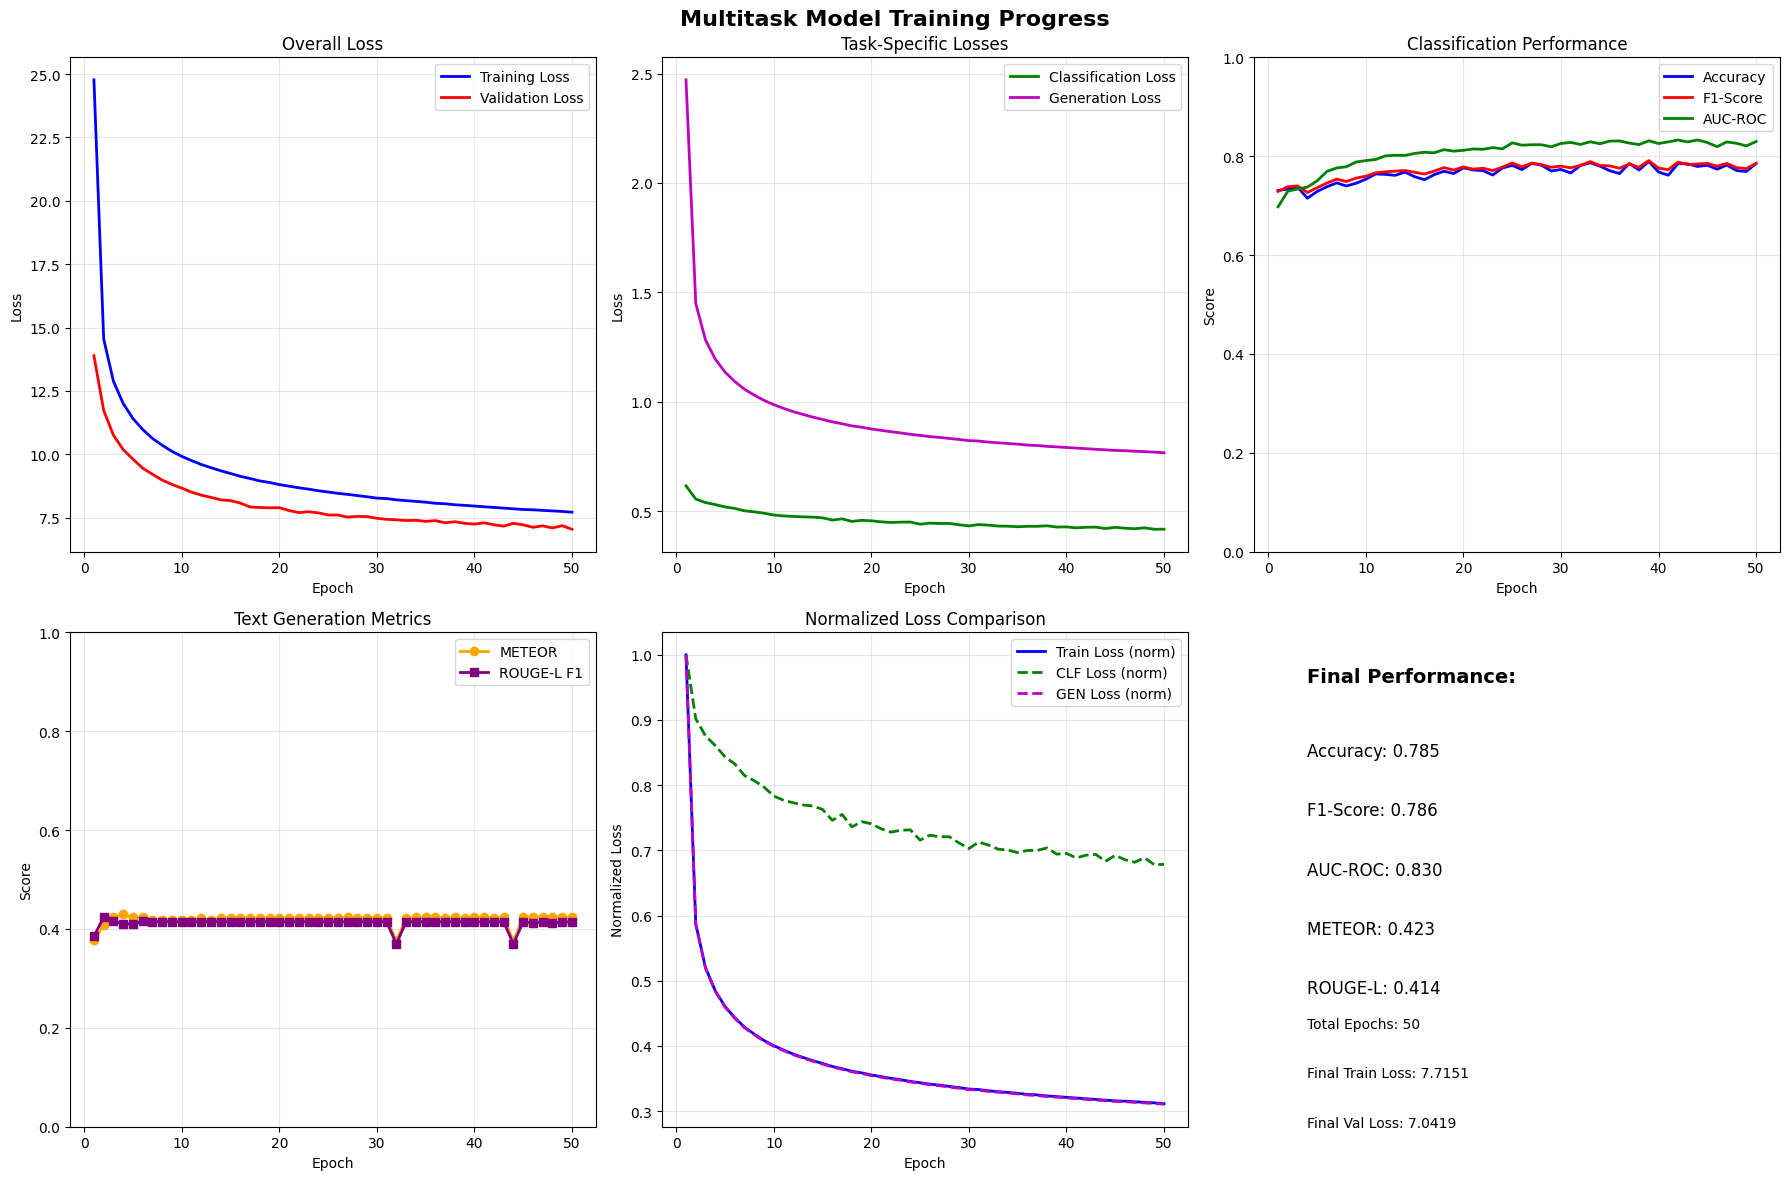


TRAINING SUMMARY
Best Accuracy: 0.7895
Best F1-Score: 0.7912
Best AUC-ROC: 0.8328
Best METEOR: 0.4293
Best ROUGE-L: 0.4237


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.9634
Classification metrics (all 3625 samples):
  Accuracy     : 0.8055
  F1-Score     : 0.8061
  Sensitivity  : 0.8690
  Specificity  : 0.6062
  AUC-ROC      : 0.8476

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4123
  METEOR       : 0.4209

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations and a follow-up breast scan in one year (May 2011). In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations and a follow-up breast scan in one year (May 2011). In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a
Reference : The measu

## Hierarchical Architecture

In [9]:
# import hierarchical modules
from hierarchy import (
    HierarchicalFeatureEncoder,        
    HierarchicalClassifier,           
    MLPFeatureProjector,              
    HierarchicalMultitaskModel,       
    HierarchicalDataset,              
    create_hierarchical_pipeline
)

In [10]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_hierarchical_pipeline(
    df_train=train_df,
    df_val=val_df, 
    df_test=test_df,          
    tokenizer_path='./t5-small-local/',
    batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    classification_weight=1.0,
    generation_weight=10.0,
)


HIERARCHICAL MULTITASK MODEL
Architecture: Hierarchical encoder + Concat projection + MLP + Minimal text
Classification weight: 1.0
Generation weight: 10.0


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Hierarchical levels: 3 + integration
  Projection mode: concat + MLP
  Text mode: minimal
  Feature dimensions: L1=256, L2=512, L3=512



Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 23.5620
Classification loss: 0.5774
Generation loss: 2.2985
Weighted gen loss: 22.984586
Validation loss: 12.6099
Validation metrics:
  Accuracy     : 0.7555
  F1-Score     : 0.7475
  Sensitivity  : 0.8657
  Specificity  : 0.4105
  AUC-ROC      : 0.7343

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4236
  ✓ New best METEOR: 0.4236
  ROUGE-L F1   : 0.4157
  ✓ New best ROUGE-L F1: 0.4157
✓ New best accuracy: 0.7555
✓ New best F1: 0.7475
✓ New best AUC-ROC: 0.7343

Epoch 2/50
Training loss: 13.4312
Classification loss: 0.5218
Generation loss: 1.2909
Weighted gen loss: 12.909374
Validation loss: 10.7889
Validation metrics:
  Accuracy     : 0.7442
  F1-Score     : 0.7484
  Sensitivity  : 0.8147
  Specificity  : 0.5234
  AUC-ROC      : 0.7576

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 sample

  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 17/50
Training loss: 8.4401
Classification loss: 0.4454
Generation loss: 0.7995
Weighted gen loss: 7.994749
Validation loss: 7.7217
Validation metrics:
  Accuracy     : 0.7569
  F1-Score     : 0.7666
  Sensitivity  : 0.7921
  Specificity  : 0.6465
  AUC-ROC      : 0.8071

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best AUC-ROC: 0.8071

Epoch 18/50
Training loss: 8.3445
Classification loss: 0.4407
Generation loss: 0.7904
Weighted gen loss: 7.903754
Validation loss: 7.6726
Validation metrics:
  Accuracy     : 0.7591
  F1-Score     : 0.7659
  Sensitivity  : 0.8103
  Specificity  : 0.5986
  AUC-ROC      : 0.8051

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
Current loss weights - CLF: 1.000, GEN: 10.000

Epoch 34/50
Training loss: 7.4117
Classification loss: 0.4078
Generation loss: 0.7004
Weighted gen loss: 7.003880
Validation loss: 7.0030
Validation metrics:
  Accuracy     : 0.7679
  F1-Score     : 0.7770
  Sensitivity  : 0.8009
  Specificity  : 0.6648
  AUC-ROC      : 0.8282

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best F1: 0.7770
✓ New best AUC-ROC: 0.8282

Epoch 35/50
Training loss: 7.3728
Classification loss: 0.4053
Generation loss: 0.6968
Weighted gen loss: 6.967517
Validation loss: 6.9778
Validation metrics:
  Accuracy     : 0.7688
  F1-Score     : 0.7765
  Sensitivity  : 0.8092
  Specificity  : 0.6420
  AUC-ROC      : 0.8189

--- Text Evaluation (Epoch 35) ---
Evaluating text generation on FULL d

Computing text metrics on 3624 samples...
  METEOR Score : 0.3647
  ROUGE-L F1   : 0.3742
✓ New best AUC-ROC: 0.8314


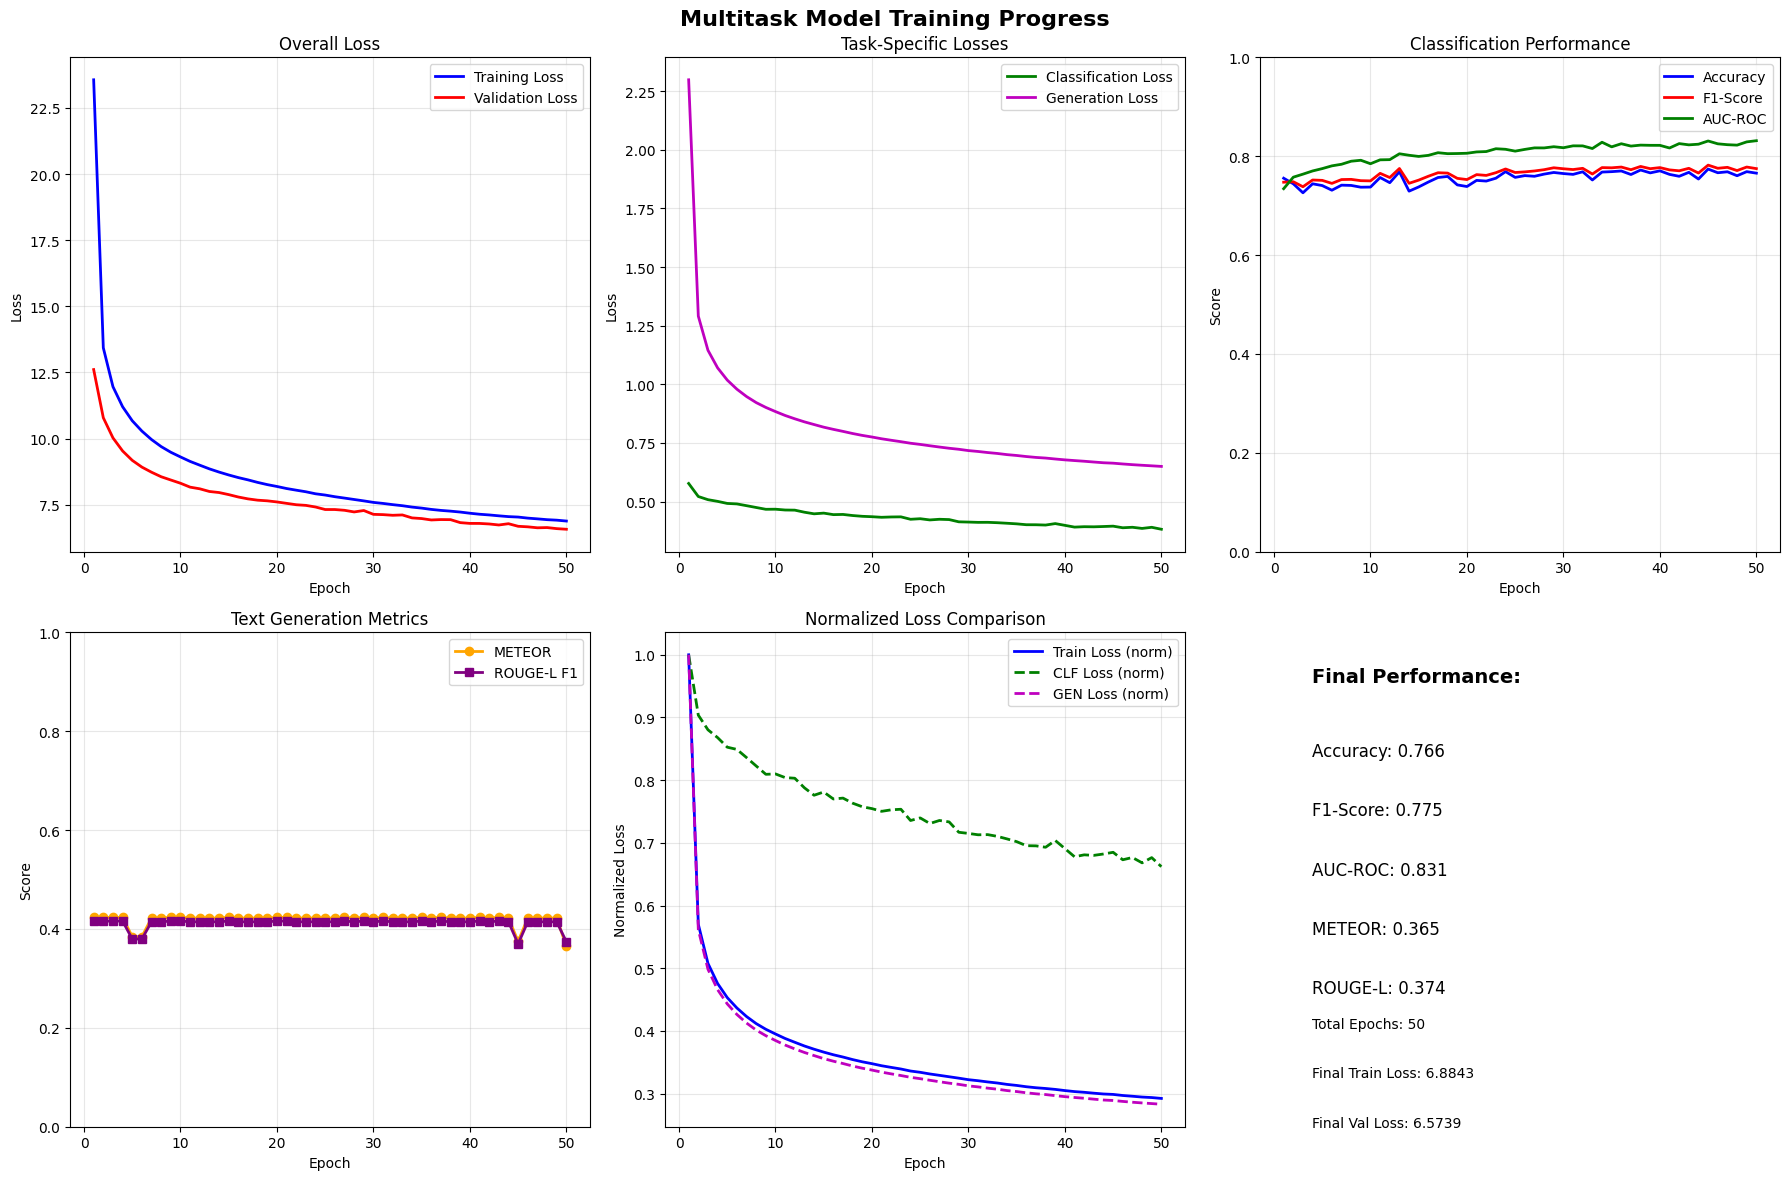


TRAINING SUMMARY
Best Accuracy: 0.7740
Best F1-Score: 0.7820
Best AUC-ROC: 0.8314
Best METEOR: 0.4236
Best ROUGE-L: 0.4160


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.4940
Classification metrics (all 3625 samples):
  Accuracy     : 0.7834
  F1-Score     : 0.7917
  Sensitivity  : 0.8123
  Specificity  : 0.6929
  AUC-ROC      : 0.8480

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3736
  METEOR       : 0.3647

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations, regular recommended preventive check-ups with a specialist, and additional diagnostics according to their opinion, as well as a repeat breast scan measurement in a year. In
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations, regular recommended preventive check-ups with a specialist, and additional diagnostics according to their opinion, as well as a repeat breast scan measurement in a year. In